<a href="https://colab.research.google.com/github/connoraking/basic_dl/blob/main/CIFAR10/notebooks/cifar10_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [314]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import tqdm as tqdm

from IPython.display import clear_output, display

import pandas as pd
from pathlib import Path

In [315]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [316]:
config ={
    "run_name": "baseline_relu",

    # training
    "batch_size": 128,
    "learning_rate": 0.001,
    "epochs": 50,

    # optimizer
    "optimizer": "adam",   # options: "adam", "sgd"

    # early stopping
    "early_stopping": True,
    "patience": 5,
    "min_delta": 0.001,

    # model
    "conv1_filters": 64,
    "conv2_filters": 128,
    "conv3_filters": 256,
    "kernel_size": 3,
    "activation": "relu",
    "dropout": 0.1,
    "num_classes": 10,

    # data
    "data_augmentation": "flip + crop"
}

# Loading Data

In [317]:
def get_train_transform(config):

    aug = config["data_augmentation"]

    if aug == "none":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])

    elif aug == "flip":
        transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])

    elif aug == "flip + crop":
        transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])

    else:
        raise ValueError("Unknown augmentation")

    return transform

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = get_train_transform(config)

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [318]:
full_train_dataset = torchvision.datasets.CIFAR10(
    root= "./data",
    train = True,
    download= True,
    transform= train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform= test_transform
)

train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Validation does NOT use train augmentation
val_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle = True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=config["batch_size"], shuffle=False, num_workers=2)

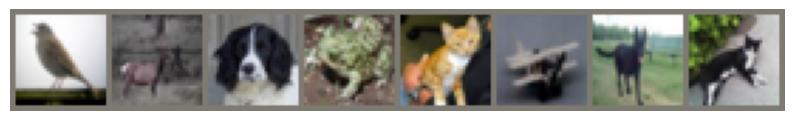

['bird', 'deer', 'dog', 'frog', 'cat', 'airplane', 'dog', 'cat']


In [319]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

def imshow(img):
    img = img * torch.tensor(std).view(3,1,1) + torch.tensor(mean).view(3,1,1)
    npimg = img.numpy()
    plt.figure(figsize=(10, 3))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

images, labels = next(iter(train_loader))
imshow(torchvision.utils.make_grid(images[:8], nrow=8).cpu())
print([classes[i] for i in labels[:8]])

# Building Model

CIFAR-10 images start as:
[batch_size, 3 (channels), 32, 32] or [B, C, H, W]

In [320]:
def get_activation(name):

    if name == "relu":
        return nn.ReLU()

    if name == "leaky_relu":
        return nn.LeakyReLU()

    if name == "gelu":
        return nn.GELU()

    if name == "tanh":
        return nn.Tanh()

    raise ValueError("Unknown activation")

In [321]:
from re import L
class SimpleCNN(nn.Module):
  def __init__(self, config):
    super().__init__()

    act = get_activation(config["activation"])

    # -------- CONV BLOCK 1

    # input: [batch, 3, 32, 32]

    self.conv1 = nn.Conv2d( # outputs [batch, conv1_filters, 32, 32]
        in_channels= 3,
        out_channels=config["conv1_filters"],
        kernel_size= config["kernel_size"],
        padding = 1
    )

    self.act1 = act

    self.pool1 = nn.MaxPool2d(2) # final layer output -> [batch, conf1_filters, 16, 16]

    # ------ CONV BLOCK 2

    self.conv2 = nn.Conv2d( # outputs [batch, conv2_filters, 16, 16]
        config["conv1_filters"],
        config["conv2_filters"],
        kernel_size= config["kernel_size"],
        padding = 1
    )

    self.act2 = act

    self.pool2 = nn.MaxPool2d(2) # final layer output -> [batch, conv2_filters, 8, 8]

    # -------- CONV BLOCK 3

    self.conv3 = nn.Conv2d( # outputs [batch, conv3_filters, 8, 8]
        config["conv2_filters"],
        config["conv3_filters"],
        kernel_size= config["kernel_size"],
        padding = 1
    )

    self.act3 = act
    self.pool3 = nn.MaxPool2d(2) # final layer output -> [batch, conv3_filters, 4, 4]

    # ----- CLASSIFIER

    self.flatten = nn.Flatten() # -> [batch, conv3_filters * 4 * 4]

    self.fc1 = nn.Linear(
        config["conv3_filters"] * 4 * 4,
        256
    )

    self.act4 = act

    self.fc2 = nn.Linear(
        256,
        config["num_classes"]
    )

    # output -> [batch, 10]

  def forward(self, x):

    # X: [batch, 3, 32, 32]

    x = self.conv1(x)
    x = self.act1(x)
    x = self.pool1(x)

    x = self.conv2(x)
    x = self.act2(x)
    x = self.pool2(x)

    x = self.conv3(x)
    x = self.act3(x)
    x = self.pool3(x)

    x = self.flatten(x)

    x = self.fc1(x)
    x = self.act4(x)

    x = self.fc2(x)

    return x



In [322]:
model = SimpleCNN(config).to(device)

print(model)

SimpleCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (act1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (act2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (act3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=256, bias=True)
  (act4): ReLU()
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


# Training Model

In [323]:
def get_optimizer(config, model):
    if config["optimizer"] == "adam":
        return optim.Adam(
            model.parameters(),
            lr=config["learning_rate"]
        )

    elif config["optimizer"] == "sgd":
        return optim.SGD(
            model.parameters(),
            lr=config["learning_rate"],
            momentum=0.9
        )

    else:
        raise ValueError("Unknown optimizer")

In [324]:
def accuracy(outputs, labels):
  _, preds = torch.max(outputs, 1)

  correct = (preds == labels).sum().item()

  return correct / labels.size(0)

In [325]:
def update_plot(train_losses, val_losses):

    epochs = list(range(len(train_losses)))

    fig, ax = plt.subplots(figsize=(6,4))

    ax.plot(epochs, train_losses, label="train")
    ax.plot(epochs, val_losses, label="validation")

    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")

    ax.set_xticks(epochs)   # integer ticks
    ax.legend()
    ax.grid(True)

    plot_handle.update(fig)
    plt.close(fig)

In [326]:
plot_handle = display(display_id=True)

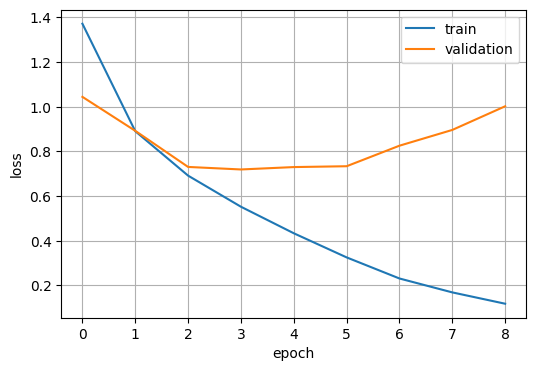

Epoch 1/50
Train loss: 1.3716
Val loss:   1.0442
Val acc:    0.6250
Saved new best model

Epoch 2/50
Train loss: 0.8905
Val loss:   0.8921
Val acc:    0.6962
Saved new best model

Epoch 3/50
Train loss: 0.6915
Val loss:   0.7305
Val acc:    0.7416
Saved new best model

Epoch 4/50
Train loss: 0.5523
Val loss:   0.7191
Val acc:    0.7590
Saved new best model

Epoch 5/50
Train loss: 0.4335
Val loss:   0.7298
Val acc:    0.7532
No improvement for 1 epoch(s)

Epoch 6/50
Train loss: 0.3255
Val loss:   0.7336
Val acc:    0.7702
No improvement for 2 epoch(s)

Epoch 7/50
Train loss: 0.2311
Val loss:   0.8256
Val acc:    0.7598
No improvement for 3 epoch(s)

Epoch 8/50
Train loss: 0.1688
Val loss:   0.8961
Val acc:    0.7662
No improvement for 4 epoch(s)

Epoch 9/50
Train loss: 0.1181
Val loss:   1.0020
Val acc:    0.7732
No improvement for 5 epoch(s)

Stopping early at epoch 9
Best epoch was 4 with val loss 0.7191


In [327]:
best_val_loss = float("inf")
best_epoch = -1
epochs_without_improvement = 0
stopped_early = False
actual_epochs_ran = 0

train_losses = []
val_losses = []
val_accuracies = []

model = SimpleCNN(config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = get_optimizer(config, model)

for epoch in range(config["epochs"]):

    actual_epochs_ran += 1

    # -----------------
    # TRAIN
    # -----------------
    model.train()
    running_train_loss = 0.0
    total_train = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)
        total_train += images.size(0)

    train_loss = running_train_loss / total_train

    # -----------------
    # VALIDATION
    # -----------------
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss = running_val_loss / total_val
    val_acc = correct / total_val

    # -----------------
    # STORE HISTORY
    # -----------------
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    update_plot(train_losses, val_losses)

    print(f"Epoch {epoch+1}/{config['epochs']}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss:   {val_loss:.4f}")
    print(f"Val acc:    {val_acc:.4f}")

    # -----------------
    # SAVE BEST MODEL
    # -----------------
    if val_loss < best_val_loss - config["min_delta"]:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        torch.save(model.state_dict(), "best_model.pt")
        print("Saved new best model")

    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s)")

    print()

    # -----------------
    # EARLY STOPPING
    # -----------------
    if config["early_stopping"] and epochs_without_improvement >= config["patience"]:
        stopped_early = True
        print(f"Stopping early at epoch {epoch+1}")
        print(f"Best epoch was {best_epoch} with val loss {best_val_loss:.4f}")
        break

# Test Set

In [328]:
best_model = SimpleCNN(config).to(device)
best_model.load_state_dict(torch.load("best_model.pt"))
best_model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_loss /= total
test_acc = correct / total

print(f"Best epoch: {best_epoch}")
print(f"Best val loss: {best_val_loss:.4f}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Best epoch: 4
Best val loss: 0.7191
Test loss: 0.7224
Test accuracy: 0.7569


# Log

In [329]:
excel_path = Path("second_log.xlsx")

new_row = {
    "run_name": f"{config['activation']}_{config['conv1_filters']}-{config['conv2_filters']}-{config['conv3_filters']}_drop{config['dropout']}_{config['data_augmentation']}",

    "conv1_filters": config["conv1_filters"],
    "conv2_filters": config["conv2_filters"],
    "conv3_filters": config["conv3_filters"],

    "kernel_size": config["kernel_size"],
    "activation": config["activation"],
    "dropout": config["dropout"],

    "optimizer": config["optimizer"],
    "learning_rate": config["learning_rate"],
    "batch_size": config["batch_size"],
    "epochs": config["epochs"],

    "early_stopping": config["early_stopping"],
    "patience": config["patience"],
    "min_delta": config["min_delta"],

    "data_augmentation": config["data_augmentation"],

    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "actual_epochs_ran": actual_epochs_ran,
    "stopped_early": stopped_early,

    "test_loss": test_loss,
    "test_accuracy": test_acc,

    "notes": "baseline run"
}

if excel_path.exists():
    df = pd.read_excel(excel_path)
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
else:
    df = pd.DataFrame([new_row])

df.to_excel(excel_path, index=False)

print(df.tail())
print(f"Saved to {excel_path}")

                              run_name  conv1_filters  conv2_filters  \
0          relu_32-64-128_drop0.0_none             32             64   
1          relu_32-64-128_drop0.3_none             32             64   
2  relu_64-128-256_drop0.3_flip + crop             64            128   
3  relu_64-128-256_drop0.3_flip + crop             64            128   
4  relu_64-128-256_drop0.1_flip + crop             64            128   

   conv3_filters  kernel_size activation  dropout optimizer  learning_rate  \
0            128            3       relu      0.0      adam         0.0010   
1            128            3       relu      0.3      adam         0.0001   
2            256            3       relu      0.3      adam         0.0001   
3            256            3       relu      0.3       sgd         0.0001   
4            256            3       relu      0.1      adam         0.0010   

   batch_size  ...  patience  min_delta  data_augmentation  best_epoch  \
0         128  ...      